# Telco Customer Churn — Modelo Preditivo com MLP (PyTorch)

**Contexto de negócio:** A Telco está perdendo clientes em ritmo acelerado. A diretoria precisa de um modelo preditivo de churn que:
- Classifique clientes com risco de cancelamento
- Quantifique o valor financeiro do churn evitado

**Estrutura do notebook:**
1. EDA Completa (volume, qualidade, distribuição, data readiness)
2. Definição de métricas técnicas e de negócio
3. Pré-processamento e feature engineering
4. MLP em PyTorch (arquitetura, ativação, loss function)
5. Avaliação e métrica de negócio (custo de churn evitado)

In [ ]:
# Instalação de dependências (execute uma vez se necessário)
# !pip install torch torchvision scikit-learn pandas matplotlib seaborn imbalanced-learn

from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.nn as nn
import torch
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    confusion_matrix, classification_report, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from scipy import stats
import seaborn as sns
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


# Sklearn

# PyTorch

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Estilo dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

print("Bibliotecas carregadas com sucesso!")
print(f"PyTorch versão: {torch.__version__}")


---
## 1. EDA Completa

### 1.1 Volume e estrutura dos dados

In [ ]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

print("=" * 55)
print("VOLUME E ESTRUTURA")
print("=" * 55)
print(f"Registros : {df.shape[0]:,}")
print(f"Features  : {df.shape[1]}")
print(f"\nTipos de dados:\n{df.dtypes.value_counts().to_string()}")
print(f"\nPrimeiras linhas:")
df.head(3)


### 1.2 Qualidade dos dados — valores ausentes e duplicados

In [ ]:
# TotalCharges foi lido como string — corrigir
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("=" * 55)
print("QUALIDADE DOS DADOS")
print("=" * 55)

# Valores ausentes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_df = pd.DataFrame({
    "Ausentes": missing,
    "Ausentes_%": missing_pct,
    "Dtype": df.dtypes
}).query("Ausentes > 0")

print(
    f"\nColunas com valores ausentes:\n{quality_df.to_string() if not quality_df.empty else '  Nenhuma (exceto TotalCharges convertida)'}")

# Duplicatas
dups = df.duplicated().sum()
print(f"\nRegistros duplicados: {dups}")

# Registros com TotalCharges nulo (clientes sem faturas — recém-contratados)
tc_null = df["TotalCharges"].isnull().sum()
print(f"\nTotalCharges nulos (clientes novos, tenure=0): {tc_null}")
print(df[df["TotalCharges"].isnull()]
      [["tenure", "MonthlyCharges", "Contract"]].to_string())


### 1.3 Distribuição da variável-alvo (Churn)

In [ ]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
axes[0].bar(churn_counts.index, churn_counts.values,
            color=["#2196F3", "#F44336"], edgecolor="white", width=0.5)
for i, (v, p) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, v + 50, f"{v:,}\n({p:.1f}%)",
                 ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Distribuição de Churn", fontsize=14)
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Clientes")

# Pie
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct="%1.1f%%", colors=["#2196F3", "#F44336"],
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proporção Churn / Não-Churn", fontsize=14)

plt.tight_layout()
plt.show()

print(
    f"\nDesbalanceamento: ratio Não-Churn / Churn = {churn_counts['No']/churn_counts['Yes']:.1f}:1")
print("=> Requer tratamento de desbalanceamento (class_weight ou oversampling)")


### 1.4 Distribuição das features numéricas

In [ ]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    # Histograma + KDE por churn
    for churn_val, color in [("No", "#2196F3"), ("Yes", "#F44336")]:
        data = df[df["Churn"] == churn_val][col].dropna()
        axes[0, i].hist(data, bins=30, alpha=0.5, color=color,
                        label=f"Churn={churn_val}", density=True)
    axes[0, i].set_title(f"Distribuição: {col}", fontsize=12)
    axes[0, i].legend()
    axes[0, i].set_xlabel(col)

    # Boxplot por churn
    df.boxplot(column=col, by="Churn", ax=axes[1, i],
               boxprops=dict(color="#333"), medianprops=dict(color="red", linewidth=2))
    axes[1, i].set_title(f"Boxplot: {col} por Churn")
    axes[1, i].set_xlabel("Churn")

plt.suptitle("")
plt.tight_layout()
plt.show()

# Estatísticas descritivas separadas por churn
print("\nEstatísticas descritivas por Churn:")
df.groupby("Churn")[num_cols].describe().round(2)


### 1.5 Distribuição das features categóricas vs Churn

In [ ]:
cat_cols = [c for c in df.select_dtypes("object").columns if c not in [
    "customerID", "Churn"]]

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    ct.plot(kind="bar", ax=axes[i], color=["#2196F3", "#F44336"],
            edgecolor="white", width=0.7)
    axes[i].set_title(f"Churn % por {col}", fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("% Churn")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(title="Churn", labels=["Não", "Sim"])
    axes[i].set_ylim(0, 100)

# Esconder eixos extras
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


### 1.6 Correlação entre features numéricas e matriz de correlação

In [ ]:
df_corr = df[num_cols + ["SeniorCitizen"]].copy()
df_corr["Churn_bin"] = (df["Churn"] == "Yes").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de correlação
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", mask=mask,
            cmap="coolwarm", center=0, ax=axes[0],
            linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title("Matriz de Correlação", fontsize=13)

# Correlação com Churn
corr_churn = df_corr.corr()["Churn_bin"].drop("Churn_bin").sort_values()
colors = ["#F44336" if v > 0 else "#2196F3" for v in corr_churn]
corr_churn.plot(kind="barh", ax=axes[1], color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlação de Pearson com Churn", fontsize=13)
axes[1].set_xlabel("Correlação")

plt.tight_layout()
plt.show()

# Teste Mann-Whitney para diferença de distribuições
print("\nTeste Mann-Whitney (p-value) — features numéricas vs Churn:")
for col in num_cols:
    g0 = df[df["Churn"] == "No"][col].dropna()
    g1 = df[df["Churn"] == "Yes"][col].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    sig = "*** SIGNIFICATIVO" if p < 0.05 else ""
    print(f"  {col:20s}: U={stat:,.0f}  p={p:.4e}  {sig}")


### 1.7 Data Readiness — resumo executivo

In [ ]:
readiness = {
    "Critério":    ["Volume", "Duplicatas", "Valores ausentes",
                    "Variável-alvo presente", "Desbalanceamento",
                    "Feature numéricas", "Features categóricas", "Pronto para modelagem"],
    "Status":      ["✅", "✅", "⚠️", "✅", "⚠️", "✅", "✅", "✅"],
    "Detalhe":     [
        "7.043 registros — adequado para MLP",
        "Zero duplicatas",
        "11 nulos em TotalCharges (tenure=0) — imputar com 0",
        "Churn (Yes/No) disponível",
        "73.5% Não-Churn vs 26.5% Churn — usar class_weight",
        "tenure, MonthlyCharges, TotalCharges — escalar com StandardScaler",
        "16 colunas — aplicar Label/One-Hot Encoding",
        "Após imputação e encoding"
    ]
}
pd.DataFrame(readiness).set_index("Critério")


---
## 2. Definição de Métricas

### 2.1 Métricas técnicas

| Métrica | Por que usar | Quando priorizar |
|---|---|---|
| **AUC-ROC** | Mede separabilidade entre classes; insensível ao threshold | Quando o threshold será ajustado depois |
| **PR-AUC** | Foca em Precision vs Recall; mais informativa em datasets desbalanceados | **Recomendada para churn** (classe minoritária importa) |
| **F1-Score** | Harmônica de Precision e Recall num único valor | Quando threshold já está fixo |

### 2.2 Métrica de negócio — Custo de Churn Evitado

A diretoria precisa de impacto financeiro, não apenas de métricas estatísticas.

**Premissas de custo:**
- `receita_mensal_media` : ticket médio do cliente (MonthlyCharges)
- `meses_retencao` : quantos meses a retenção prolonga o contrato (ex: 12)
- `custo_campanha` : custo da ação de retenção por cliente contatado (ex: R$ 50)
- `taxa_sucesso_retencao` : % de clientes que de fato ficam quando contatados (ex: 30%)

**Fórmula:**
```
valor_cliente = receita_mensal_media × meses_retencao
churn_evitado = TP × taxa_sucesso_retencao × valor_cliente
custo_campanha_total = (TP + FP) × custo_campanha
lucro_liquido = churn_evitado - custo_campanha_total
```
- `TP` = verdadeiros positivos (churn detectado corretamente)
- `FP` = falsos positivos (não-churn tratado desnecessariamente)

In [ ]:
def custo_churn_evitado(y_true, y_pred, y_prob=None, threshold=0.5,
                        meses_retencao=12, custo_campanha=50.0,
                        taxa_sucesso=0.30, receita_mensal=None):
    """
    Calcula o lucro líquido da campanha de retenção baseada no modelo.

    Parâmetros
    ----------
    y_true          : array binário real
    y_pred          : array binário previsto (ou calculado a partir de y_prob + threshold)
    y_prob          : probabilidades do modelo (opcional, substitui y_pred se fornecido)
    threshold       : ponto de corte para classificação
    meses_retencao  : janela de receita recuperada por cliente retido
    custo_campanha  : custo fixo por cliente contatado (R$)
    taxa_sucesso    : taxa de retenção efetiva da campanha
    receita_mensal  : receita mensal média (se None, usa 65.0 como proxy)
    """
    if receita_mensal is None:
        receita_mensal = 65.0  # ticket médio aproximado do dataset

    if y_prob is not None:
        y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    valor_cliente = receita_mensal * meses_retencao
    receita_recuperada = tp * taxa_sucesso * valor_cliente
    custo_total_campanha = (tp + fp) * custo_campanha
    lucro_liquido = receita_recuperada - custo_total_campanha

    resultado = {
        "TP (churn detectado)":           int(tp),
        "FP (falso alarme)":              int(fp),
        "FN (churn perdido)":             int(fn),
        "TN (não-churn correto)":         int(tn),
        "Clientes contatados":            int(tp + fp),
        "Receita recuperada (R$)":        round(receita_recuperada, 2),
        "Custo campanha (R$)":            round(custo_total_campanha, 2),
        "Lucro líquido (R$)":             round(lucro_liquido, 2),
    }
    return resultado


print("Função `custo_churn_evitado` definida.")
print("\nPremissas padrão:")
print("  - Receita mensal média  : R$ 65,00")
print("  - Meses de retenção     : 12")
print("  - Custo por contato     : R$ 50,00")
print("  - Taxa sucesso campanha : 30%")


---
## 3. Pré-processamento + Baseline

### 3.1 Pré-processamento

### 3.0 Feature Engineering

Novas features criadas a partir do domínio de negócio:

| Feature | Fórmula | Insight |
|---|---|---|
| `charges_per_month` | `TotalCharges / (tenure + 1)` | Ticket médio real do cliente |
| `is_monthly` | `Contract == Month-to-month` | Clientes mensais cancelam mais |
| `has_no_services` | sem segurança + suporte + backup | Cliente sem serviços tem menos lock-in |
| `service_count` | soma de serviços contratados | Quanto mais serviços, menor o churn |
| `is_senior_alone` | idoso sem parceiro | Grupo de alto risco |
| `charges_x_monthly` | `MonthlyCharges × is_monthly` | Interação custo + tipo contrato |

In [ ]:
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Garantir que TotalCharges não tenha NaN antes das operações
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"], errors="coerce"
    ).fillna(0)

    # Ticket médio mensal real
    # Para tenure=0: usa MonthlyCharges como proxy (cliente sem fatura ainda)
    # Para tenure>0: TotalCharges / tenure  (sem +1 — evita viés sistemático)
    df["charges_per_month"] = np.where(
        df["tenure"] == 0,
        df["MonthlyCharges"],
        df["TotalCharges"] / df["tenure"]
    )

    # Flag: contrato mensal (maior risco de churn)
    df["is_monthly"] = (
        df["Contract"] == "Month-to-month"
    ).astype(int)

    # Contagem de serviços contratados
    service_cols = [
        "OnlineSecurity", "OnlineBackup", "DeviceProtection",
        "TechSupport", "StreamingTV", "StreamingMovies",
    ]
    df["service_count"] = df[service_cols].apply(
        lambda row: (row == "Yes").sum(), axis=1
    )

    # Sem nenhum serviço adicional (menor lock-in)
    df["has_no_services"] = (df["service_count"] == 0).astype(int)

    # Idoso sem parceiro (grupo de alto risco identificado na EDA)
    df["is_senior_alone"] = (
        (df["SeniorCitizen"] == 1) & (df["Partner"] == "No")
    ).astype(int)

    # Interação: custo alto + contrato mensal
    df["charges_x_monthly"] = (
        df["MonthlyCharges"] * df["is_monthly"]
    )

    return df


# Aplicar antes do encoding
df = feature_engineering(df)

new_feats = [
    "charges_per_month", "is_monthly", "service_count",
    "has_no_services", "is_senior_alone", "charges_x_monthly",
]

# Verificar NaN nas novas features
nan_check = df[new_feats].isnull().sum()
print("NaN por feature (deve ser 0):")
print(nan_check.to_string())

print("\nMédia por grupo Churn:\n")
print(df[new_feats + ["Churn"]].groupby("Churn")[new_feats].mean().round(3).T.to_string())

# Correlação com Churn
churn_bin = (df["Churn"] == "Yes").astype(int)
corr_new = df[new_feats].corrwith(churn_bin).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#F44336" if v > 0 else "#2196F3" for v in corr_new]
corr_new.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Correlação das novas features com Churn", fontsize=13)
ax.set_xlabel("Correlação de Pearson")
plt.tight_layout()
plt.show()


In [19]:
from sklearn.impute import SimpleImputer

df_model = df.copy()

# 1. Remover ID
df_model.drop(columns=["customerID"], inplace=True)

# 2. Codificar target
df_model["Churn"] = (df_model["Churn"] == "Yes").astype(int)

# 3. One-Hot Encoding nas categóricas
cat_features = df_model.select_dtypes("object").columns.tolist()
df_model = pd.get_dummies(df_model, columns=cat_features, drop_first=True)

# 4. Separar X e y
X = df_model.drop(columns=["Churn"]).astype(float)
y = df_model["Churn"].values

# 5. Verificar e reportar NaN antes de imputar
nan_cols = X.isnull().sum()
nan_cols = nan_cols[nan_cols > 0]
if not nan_cols.empty:
    print("Colunas com NaN (serão imputadas com mediana):")
    print(nan_cols.to_string())
else:
    print("Nenhum NaN encontrado.")

# 6. Imputar NaN com mediana (robusto a outliers)
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)

# 7. Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=SEED, stratify=y
)

# 8. Escalonamento
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Guardar nomes das features para o RF
feat_names = X.columns.tolist()

print(f"\nFeatures totais : {X_train_sc.shape[1]}")
print(f"Treino          : {X_train_sc.shape[0]}")
print(f"Teste           : {X_test_sc.shape[0]}")
print(f"Churn no treino : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Churn no teste  : {y_test.sum()} ({y_test.mean()*100:.1f}%)")


Features após encoding : 36
Treino : 5634 | Teste : 1409
Churn no treino : 1495 (26.5%)
Churn no teste  : 374 (26.5%)


### 3.2 Helper de avaliação unificado

In [20]:
resultados_modelos = {}   # acumula métricas de todos os modelos


def avaliar_modelo(nome, y_true, y_prob, threshold=0.5, verbose=True):
    """Calcula e exibe métricas técnicas + métrica de negócio."""
    y_pred = (y_prob >= threshold).astype(int)

    auc_roc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    negocio = custo_churn_evitado(y_true, y_pred)

    resultados_modelos[nome] = {
        "AUC-ROC": round(auc_roc, 4),
        "PR-AUC":  round(pr_auc, 4),
        "F1":      round(f1, 4),
        "Lucro_liquido_R$": negocio["Lucro líquido (R$)"],
    }

    if verbose:
        print(f"\n{'='*55}")
        print(f"  MODELO: {nome}")
        print(f"{'='*55}")
        print(f"  AUC-ROC : {auc_roc:.4f}")
        print(f"  PR-AUC  : {pr_auc:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        print(f"\n  --- Métrica de Negócio ---")
        for k, v in negocio.items():
            print(f"  {k:<30}: {v:>10,}")
        print()

        # Gráficos de avaliação
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        # Curva ROC
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        axes[0].plot(fpr, tpr, color="#F44336", lw=2,
                     label=f"AUC={auc_roc:.3f}")
        axes[0].plot([0, 1], [0, 1], "k--", lw=1)
        axes[0].set(title=f"ROC — {nome}", xlabel="FPR", ylabel="TPR")
        axes[0].legend()

        # Curva Precision-Recall
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        axes[1].plot(rec, prec, color="#2196F3", lw=2,
                     label=f"PR-AUC={pr_auc:.3f}")
        axes[1].axhline(y_true.mean(), color="gray", lw=1,
                        linestyle="--", label="Baseline")
        axes[1].set(
            title=f"Precision-Recall — {nome}", xlabel="Recall", ylabel="Precision")
        axes[1].legend()

        # Matriz de confusão
        ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                               display_labels=["Não-Churn", "Churn"]).plot(ax=axes[2], colorbar=False)
        axes[2].set_title(f"Matriz de Confusão — {nome}")

        plt.tight_layout()
        plt.show()

    return resultados_modelos[nome]


print("Helper `avaliar_modelo` definido.")


Helper `avaliar_modelo` definido.


### 3.3 Baseline — DummyClassifier

O `DummyClassifier` com estratégia `stratified` não aprende nenhum padrão — apenas replica a distribuição da classe. Serve como **piso mínimo**: qualquer modelo real deve superá-lo.


  MODELO: DummyClassifier (stratified)
  AUC-ROC : 0.5163
  PR-AUC  : 0.2723
  F1-Score: 0.2903

  --- Métrica de Negócio ---
  TP (churn detectado)          :        109
  FP (falso alarme)             :        268
  FN (churn perdido)            :        265
  TN (não-churn correto)        :        767
  Clientes contatados           :        377
  Receita recuperada (R$)       :   25,506.0
  Custo campanha (R$)           :   18,850.0
  Lucro líquido (R$)            :    6,656.0



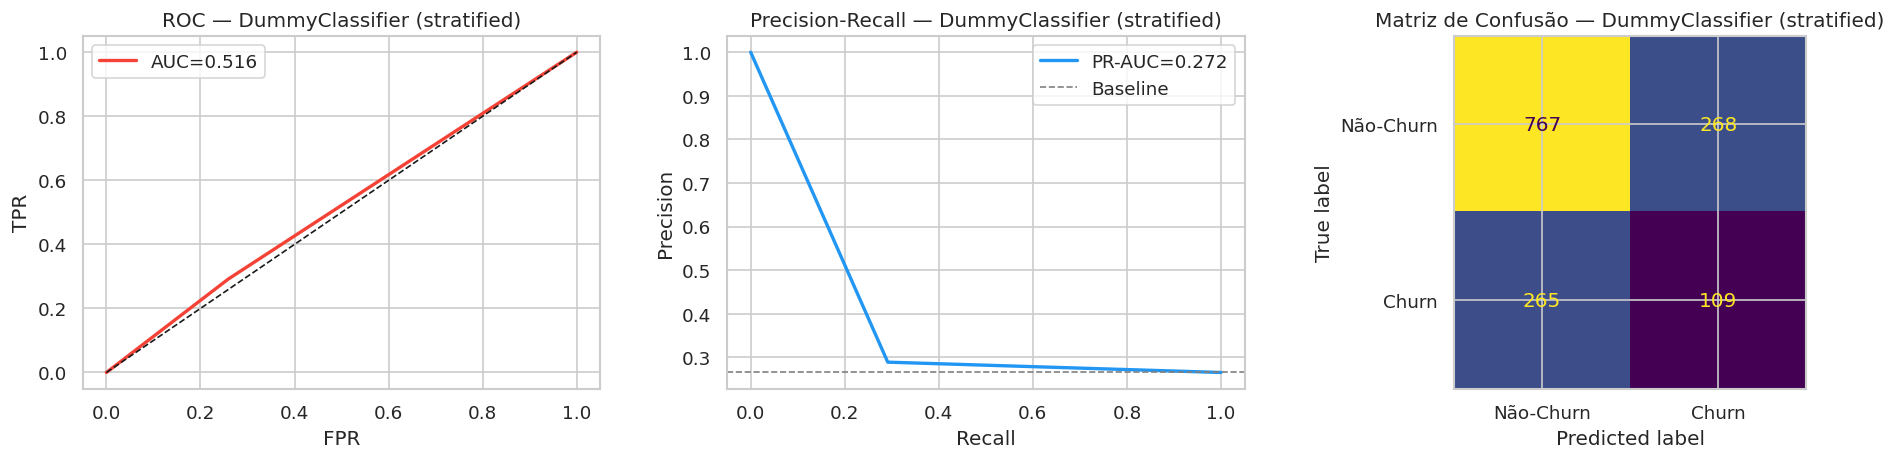

{'AUC-ROC': 0.5163,
 'PR-AUC': 0.2723,
 'F1': 0.2903,
 'Lucro_liquido_R$': np.float64(6656.0)}

In [24]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="stratified", random_state=SEED)
dummy.fit(X_train_sc, y_train)
dummy_prob = dummy.predict_proba(X_test_sc)[:, 1]

avaliar_modelo("DummyClassifier (stratified)", y_test, dummy_prob)


### 3.4 Baseline — Regressão Logística

Modelo linear interpretável. Serve como **referência inteligente**: captura padrões lineares e gera probabilidades bem calibradas. O MLP precisa superar este baseline para justificar sua complexidade.

In [25]:
from sklearn.linear_model import LogisticRegression

# class_weight='balanced' compensa o desbalanceamento automaticamente
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED,
    solver="lbfgs"
)
lr.fit(X_train_sc, y_train)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]

avaliar_modelo("Regressão Logística", y_test, lr_prob)

# Coeficientes mais relevantes
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coeficiente": lr.coef_[0]
}).sort_values("coeficiente", key=abs, ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#F44336" if c > 0 else "#2196F3" for c in coef_df["coeficiente"]]
ax.barh(coef_df["feature"], coef_df["coeficiente"],
        color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title(
    "Top 12 coeficientes — Regressão Logística\n(vermelho=aumenta churn, azul=diminui)", fontsize=12)
ax.set_xlabel("Coeficiente")
plt.tight_layout()
plt.show()


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### 3.5 Random Forest — Feature Importance, SHAP & Seleção de Features

O RF cumpre três papéis aqui:
1. **Baseline robusto** — supera LR em datasets tabulares com interações
2. **Ranqueamento de features** — `feature_importances_` + importância por permutação
3. **SHAP values** — explica *por que* cada cliente tem aquela probabilidade de churn

As features selecionadas pelo RF alimentarão o MLP, reduzindo ruído e acelerando o treino.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import shap

# ── 1. Treinar Random Forest ──────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_train_sc, y_train)
rf_prob = rf.predict_proba(X_test_sc)[:, 1]

avaliar_modelo("Random Forest", y_test, rf_prob)

# ── 2. Feature Importance (impurity) ─────────────────────────
feat_names = X.columns.tolist()
fi = pd.Series(rf.feature_importances_, index=feat_names)
fi_top20 = fi.sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fi_top20.sort_values().plot(
    kind="barh", ax=axes[0],
    color="#4CAF50", edgecolor="white"
)
axes[0].set_title("Top 20 — Importância por Impureza (RF)", fontsize=12)
axes[0].set_xlabel("Importância média")

# ── 3. Importância por Permutação ────────────────────────────
perm = permutation_importance(
    rf, X_test_sc, y_test,
    n_repeats=10, random_state=SEED, n_jobs=-1,
    scoring="roc_auc"
)
perm_series = pd.Series(
    perm.importances_mean, index=feat_names
).sort_values(ascending=False).head(20)

perm_series.sort_values().plot(
    kind="barh", ax=axes[1],
    color="#2196F3", edgecolor="white"
)
axes[1].set_title(
    "Top 20 — Importância por Permutação (AUC-ROC)", fontsize=12
)
axes[1].set_xlabel("Queda média no AUC-ROC")
plt.tight_layout()
plt.show()

# ── 4. SHAP values ────────────────────────────────────────────
print("\nCalculando SHAP values (TreeExplainer)...")
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_sc)

# Compatível com SHAP >= 0.42 (3D) e versões antigas (lista)
if isinstance(shap_values, list):
    shap_arr = shap_values[1]          # lista: índice 1 = classe positiva
elif shap_values.ndim == 3:
    shap_arr = shap_values[:, :, 1]    # 3D: (amostras, features, classes)
else:
    shap_arr = shap_values             # 2D direto

# SHAP beeswarm
shap.summary_plot(
    shap_arr, X_test_sc,
    feature_names=feat_names,
    plot_type="dot",
    max_display=15,
    show=False,
)
plt.title("SHAP — Impacto individual por cliente (beeswarm)", fontsize=13)
plt.tight_layout()
plt.show()

# SHAP bar
shap.summary_plot(
    shap_arr, X_test_sc,
    feature_names=feat_names,
    plot_type="bar",
    max_display=15,
    show=False,
)
plt.title("SHAP — Importância global média", fontsize=13)
plt.tight_layout()
plt.show()

# ── 5. Selecionar features com 90% da importância acumulada ───
fi_sorted = fi.sort_values(ascending=False)
cumsum = fi_sorted.cumsum() / fi_sorted.sum()
TOP_FEATURES = fi_sorted[cumsum <= 0.90].index.tolist()

if len(TOP_FEATURES) < 10:
    TOP_FEATURES = fi_sorted.head(10).index.tolist()

print(f"\nFeatures selecionadas (90% importância acumulada):")
print(f"  {len(TOP_FEATURES)} de {len(feat_names)} features")
print(f"  {TOP_FEATURES}")


---
## 4. MLP em PyTorch

### 4.1 Arquitetura

**Decisões de design:**

| Componente | Escolha | Justificativa |
|---|---|---|
| Camadas ocultas | 3 camadas (128 → 64 → 32) | Profundidade suficiente para capturar não-linearidades sem overfitting no volume de dados |
| Ativação | **ReLU** | Evita vanishing gradient; padrão para classificação tabular |
| Regularização | **BatchNorm + Dropout(0.3)** | BatchNorm estabiliza treinamento; Dropout previne overfitting |
| Saída | **Sigmoid** | Produz probabilidade [0,1] para classificação binária |
| Loss | **BCEWithLogitsLoss** | Numericamente estável; aceita `pos_weight` para desbalanceamento |
| Otimizador | **Adam** com LR scheduling | Convergência rápida; `ReduceLROnPlateau` evita plateau |

In [ ]:
class ChurnMLP(nn.Module):
    """
    MLP para classificação binária de churn.
    Recebe apenas as features selecionadas pelo Random Forest.

    Arquitetura:
        Input (top RF features)
        → [Linear → BatchNorm → ReLU → Dropout] x 3
        → Linear(1)
    """

    def __init__(
        self, input_dim: int,
        hidden_dims=(128, 64, 32),
        dropout=0.3
    ):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(1)


# INPUT_DIM = número de features selecionadas pelo RF
INPUT_DIM = len(TOP_FEATURES)
model_preview = ChurnMLP(INPUT_DIM)
print(model_preview)
total_params = sum(
    p.numel() for p in model_preview.parameters() if p.requires_grad
)
print(f"\nFeatures de entrada (RF): {INPUT_DIM}")
print(f"Parâmetros treináveis   : {total_params:,}")


### 4.2 Preparação dos DataLoaders e class weight

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 256
EPOCHS = 80
LR = 1e-3

print(f"Dispositivo: {DEVICE}")
print(f"Features selecionadas pelo RF: {len(TOP_FEATURES)}")

# ── Filtrar apenas as features selecionadas pelo RF ───────────
X_train_rf = X_train_sc[:, [feat_names.index(f) for f in TOP_FEATURES]]
X_test_rf = X_test_sc[:, [feat_names.index(f) for f in TOP_FEATURES]]

# ── Tensores ──────────────────────────────────────────────────
X_tr = torch.tensor(X_train_rf, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.float32)
X_te = torch.tensor(X_test_rf, dtype=torch.float32)
y_te = torch.tensor(y_test, dtype=torch.float32)

train_ds = TensorDataset(X_tr, y_tr)
test_ds = TensorDataset(X_te, y_te)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False
)

# pos_weight = n_negativos / n_positivos
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight = torch.tensor(
    [n_neg / n_pos], dtype=torch.float32
).to(DEVICE)

print(f"pos_weight = {pos_weight.item():.2f}  (ratio Não-Churn / Churn)")
print(f"Shape treino : {X_tr.shape}")
print(f"Shape teste  : {X_te.shape}")


### 4.3 Loop de treinamento

In [ ]:
import mlflow
import mlflow.pytorch
import os

# Configurar tracking URI para usar o mesmo diretório do outro notebook
mlruns_dir = "../mlruns"
os.makedirs(mlruns_dir, exist_ok=True)
mlflow.set_tracking_uri(f"file:{mlruns_dir}")

mlflow.set_experiment("telco-churn")


def treinar_mlp(
    model, train_loader, test_loader,
    epochs, lr, pos_weight, device,
    patience=10, run_name="mlp"
):
    """Loop de treino com early stopping e logging MLflow."""
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(
        model.parameters(), lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=5, factor=0.5
    )

    history = {"train_loss": [], "val_loss": [], "val_auc": []}

    # Early stopping
    best_val_loss = float("inf")
    best_weights = None
    patience_counter = 0

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({
            "epochs": epochs,
            "lr": lr,
            "batch_size": train_loader.batch_size,
            "patience": patience,
            "input_dim": next(iter(train_loader))[0].shape[1],
            "pos_weight": pos_weight.item(),
        })

        for epoch in range(1, epochs + 1):
            # ── Treino ───────────────────────────────────────
            model.train()
            running_loss = 0.0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * xb.size(0)

            train_loss = running_loss / len(train_loader.dataset)

            # ── Validação ────────────────────────────────────
            model.eval()
            val_loss_acc = 0.0
            all_probs, all_labels = [], []

            with torch.no_grad():
                for xb, yb in test_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    logits = model(xb)
                    val_loss_acc += (
                        criterion(logits, yb).item() * xb.size(0)
                    )
                    probs = torch.sigmoid(logits).cpu().numpy()
                    all_probs.extend(probs)
                    all_labels.extend(yb.cpu().numpy())

            val_loss = val_loss_acc / len(test_loader.dataset)
            val_auc = roc_auc_score(all_labels, all_probs)
            scheduler.step(val_loss)

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["val_auc"].append(val_auc)

            mlflow.log_metrics({
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_auc": val_auc,
            }, step=epoch)

            # ── Early stopping ────────────────────────────────
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_weights = {
                    k: v.clone()
                    for k, v in model.state_dict().items()
                }
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(
                        f"Early stopping na época {epoch} "
                        f"(melhor val_loss={best_val_loss:.4f})"
                    )
                    break

            if epoch % 10 == 0 or epoch == 1:
                lr_atual = optimizer.param_groups[0]["lr"]
                print(
                    f"Epoch {epoch:3d}/{epochs} | "
                    f"train={train_loss:.4f} | "
                    f"val={val_loss:.4f} | "
                    f"AUC={val_auc:.4f} | "
                    f"lr={lr_atual:.2e} | "
                    f"patience={patience_counter}/{patience}"
                )

        # Restaurar melhores pesos
        model.load_state_dict(best_weights)
        mlflow.pytorch.log_model(model, "model")
        print(f"\nMelhor val_loss: {best_val_loss:.4f}")

    return (
        model, history,
        np.array(all_probs), np.array(all_labels)
    )


mlp = ChurnMLP(INPUT_DIM)
mlp, history, mlp_prob, mlp_labels = treinar_mlp(
    mlp, train_loader, test_loader,
    epochs=EPOCHS, lr=LR,
    pos_weight=pos_weight, device=DEVICE,
    patience=10, run_name="mlp-churn"
)


### 4.4 Curvas de aprendizado

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_range = range(1, EPOCHS + 1)

# Loss
axes[0].plot(epochs_range, history["train_loss"],
             label="Train Loss", color="#2196F3")
axes[0].plot(epochs_range, history["val_loss"],
             label="Val Loss",   color="#F44336")
axes[0].set_title("BCE Loss por Época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

# AUC-ROC
axes[1].plot(epochs_range, history["val_auc"],
             label="Val AUC-ROC", color="#4CAF50", lw=2)
axes[1].axhline(resultados_modelos.get("Regressão Logística", {}).get("AUC-ROC", 0),
                color="gray", linestyle="--", label="LR baseline")
axes[1].set_title("AUC-ROC por Época (validação)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("AUC-ROC")
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()

plt.tight_layout()
plt.show()


### 4.5 Avaliação do MLP e otimização de threshold

In [ ]:
# --- Avaliação com threshold padrão (0.5) ---
avaliar_modelo("MLP (PyTorch)", mlp_labels, mlp_prob, threshold=0.5)

# --- Threshold p80: classifica como churn o top 20% de maior probabilidade ---
threshold_p80 = np.percentile(mlp_prob, 80)
print(
    f"\nThreshold p80 = {threshold_p80:.4f}  (top 20% clientes com maior risco)")
avaliar_modelo("MLP (PyTorch) — p80", mlp_labels,
               mlp_prob, threshold=threshold_p80)

# --- Otimização de threshold pela métrica de negócio ---
thresholds = np.arange(0.2, 0.7, 0.02)
lucros = []
for t in thresholds:
    neg = custo_churn_evitado(mlp_labels, None, y_prob=mlp_prob, threshold=t)
    lucros.append(neg["Lucro líquido (R$)"])

best_idx = np.argmax(lucros)
best_threshold = thresholds[best_idx]
best_lucro = lucros[best_idx]
lucro_p80 = custo_churn_evitado(mlp_labels, None, y_prob=mlp_prob,
                                threshold=threshold_p80)["Lucro líquido (R$)"]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(thresholds, lucros, color="#4CAF50", lw=2, marker="o", markersize=4)
ax.axvline(best_threshold, color="#F44336", linestyle="--",
           label=f"Melhor threshold={best_threshold:.2f} → R$ {best_lucro:,.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="Threshold padrão (0.5)")
ax.axvline(threshold_p80, color="#FF9800", linestyle="-.",
           label=f"p80={threshold_p80:.2f} → R$ {lucro_p80:,.2f}")
ax.set_title("Lucro Líquido da Campanha × Threshold de Classificação")
ax.set_xlabel("Threshold")
ax.set_ylabel("Lucro Líquido (R$)")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
plt.tight_layout()
plt.show()

print(f"\n{'Critério':<30} {'Threshold':>10} {'Lucro líquido':>18}")
print("-" * 60)
lucro_05 = custo_churn_evitado(mlp_labels, None, y_prob=mlp_prob, threshold=0.5)[
    "Lucro líquido (R$)"]
print(f"{'Threshold padrão (0.5)':<30} {'0.50':>10} {'R$ ' + f'{lucro_05:,.2f}':>18}")
print(f"{'Percentil 80 (p80)':<30} {threshold_p80:>10.2f} {'R$ ' + f'{lucro_p80:,.2f}':>18}")
print(f"{'Otimizado (negócio)':<30} {best_threshold:>10.2f} {'R$ ' + f'{best_lucro:,.2f}':>18}")


---
## 5. Comparação Completa — ≥ 4 Métricas + Trade-off de Custo


=== MÉTRICAS DE RANKING (independentes de threshold) ===


,AUC-ROC,PR-AUC,KS Stat
Modelo,,,
DummyClassifier,0.5163,0.2723,0.0325
Regressão Logística,0.8464,0.6604,0.5301
Random Forest,0.8409,0.6468,0.5543
MLP (0.5),0.8364,0.6536,0.5209
MLP (p80),0.8364,0.6536,0.5209



=== MÉTRICAS DE THRESHOLD (threshold=0.5 ou p80) ===


,F1,MCC,Balanced Acc,G-Mean,Precision,Recall,Specificity
Modelo,,,,,,,
DummyClassifier,0.2903,0.0324,0.5163,0.4647,0.2891,0.2914,0.7411
Regressão Logística,0.6243,0.4701,0.7624,0.7614,0.5111,0.8021,0.7227
Random Forest,0.6300,0.4802,0.7577,0.7567,0.5604,0.7193,0.7961
MLP (0.5),0.6193,0.4618,0.7566,0.7562,0.5132,0.7807,0.7324
MLP (p80),0.5671,0.4465,0.7023,0.6717,0.6596,0.4973,0.9072



=== CALIBRAÇÃO PROBABILÍSTICA ===


,Brier Score,Log Loss
Modelo,,
DummyClassifier,0.3783,13.6347
Regressão Logística,0.1656,0.4888
Random Forest,0.1497,0.4546
MLP (0.5),0.1718,0.5050
MLP (p80),0.1718,0.5050


  * Brier Score: menor = melhor | Log Loss: menor = melhor

=== MÉTRICAS DE NEGÓCIO ===


,Precision@374,Lift@374,Lucro_R$
Modelo,,,
DummyClassifier,0.2914,1.0980,6656.0
Regressão Logística,0.6070,2.2866,40850.0
Random Forest,0.6016,2.2665,38946.0
MLP (0.5),0.5963,2.2463,39878.0
MLP (p80),0.5963,2.2463,29424.0


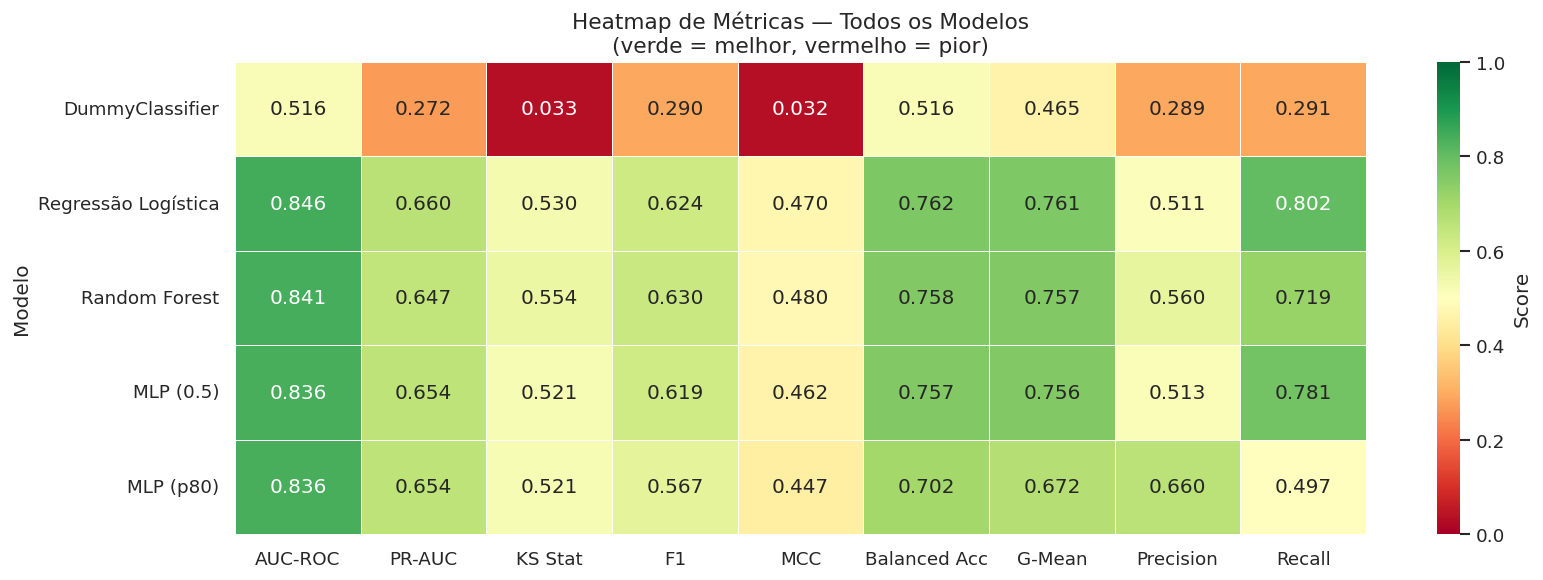


=== TRADE-OFF DE CUSTO: FP vs FN ===
Custo FP (campanha desperdiçada) : R$ 50/cliente
Custo FN (receita perdida)       : R$ 780/cliente
Ratio FN/FP                      : 15x



,FP,FN,Custo FP (R$),Custo FN (R$),Custo Total (R$)
Modelo,,,,,
DummyClassifier,268,265,13400,206700,220100
Regressão Logística,287,74,14350,57720,72070
Random Forest,211,105,10550,81900,92450
MLP (0.5),277,82,13850,63960,77810
MLP (p80),96,188,4800,146640,151440


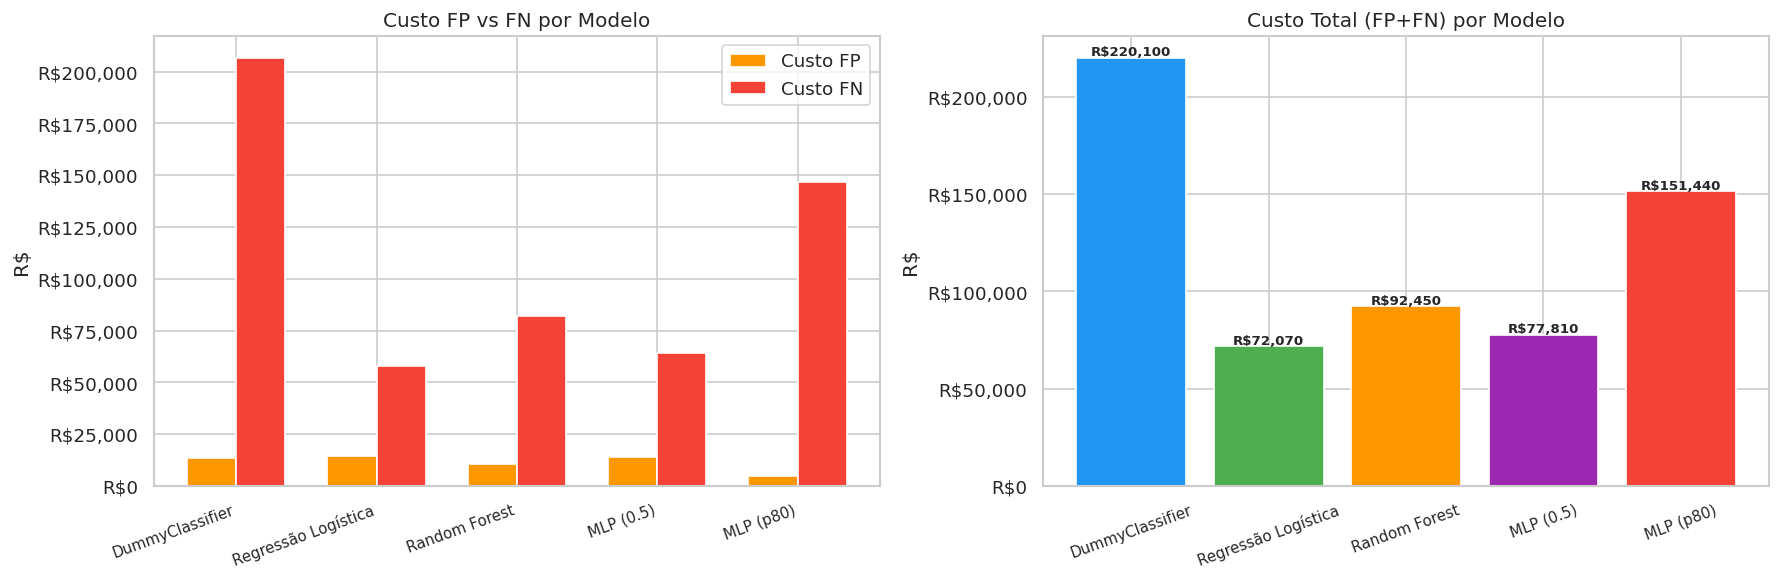


Modelo com menor custo total: Regressão Logística
Custo total: R$ 72,070.00


In [39]:
from sklearn.metrics import (
    matthews_corrcoef, balanced_accuracy_score,
    brier_score_loss, log_loss, fbeta_score
)
from scipy import stats as scipy_stats


def precision_at_k(y_true, y_prob, k=None):
    """Precision nos top-K clientes com maior probabilidade."""
    if k is None:
        k = int(y_true.sum())
    top_k_idx = np.argsort(y_prob)[::-1][:k]
    return y_true[top_k_idx].sum() / k


def lift_at_k(y_true, y_prob, k=None):
    """Lift nos top-K: quanto o modelo supera o aleatório."""
    if k is None:
        k = int(y_true.sum())
    prec_k = precision_at_k(y_true, y_prob, k)
    baseline = y_true.mean()
    return prec_k / baseline if baseline > 0 else 0


def ks_statistic(y_true, y_prob):
    """KS Statistic: separação máxima entre distribuições churn/não-churn."""
    prob_churn = y_prob[y_true == 1]
    prob_no_churn = y_prob[y_true == 0]
    ks, _ = scipy_stats.ks_2samp(prob_churn, prob_no_churn)
    return ks


def g_mean(y_true, y_pred):
    """Média geométrica de Sensitivity e Specificity."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return np.sqrt(sensitivity * specificity)


def metricas_completas(nome, y_true, y_prob, threshold=0.5):
    """
    Suite completa de métricas — visão acadêmica MLE (FIAP).

    Técnicas de ranking    : AUC-ROC, PR-AUC, KS Statistic
    Técnicas de threshold  : F1, F2, MCC, Balanced Acc, G-Mean,
                             Precision, Recall, Specificity
    Calibração             : Brier Score, Log Loss
    Negócio                : Precision@K, Lift@K, Lucro Líquido

    Por que F2 para churn?
    ----------------------
    F-beta pondera Recall β² vezes mais que Precision.
    Com β=2: custo de FN (cliente perdido) >> custo de FP
    (campanha desperdiçada), refletindo a assimetria real do negócio.
    """
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision  = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall     = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    negocio    = custo_churn_evitado(y_true, y_pred)
    k          = int(y_true.sum())

    return {
        "Modelo":           nome,
        # Ranking (threshold-free)
        "AUC-ROC":          round(roc_auc_score(y_true, y_prob), 4),
        "PR-AUC":           round(average_precision_score(y_true, y_prob), 4),
        "KS Stat":          round(ks_statistic(y_true, y_prob), 4),
        # Threshold-dependent
        "F2":               round(fbeta_score(y_true, y_pred, beta=2), 4),
        "F1":               round(f1_score(y_true, y_pred), 4),
        "MCC":              round(matthews_corrcoef(y_true, y_pred), 4),
        "Balanced Acc":     round(balanced_accuracy_score(y_true, y_pred), 4),
        "G-Mean":           round(g_mean(y_true, y_pred), 4),
        "Precision":        round(precision, 4),
        "Recall":           round(recall, 4),
        "Specificity":      round(specificity, 4),
        # Calibração
        "Brier Score":      round(brier_score_loss(y_true, y_prob), 4),
        "Log Loss":         round(log_loss(y_true, y_prob), 4),
        # Negócio
        f"Precision@{k}":   round(precision_at_k(y_true, y_prob, k), 4),
        f"Lift@{k}":        round(lift_at_k(y_true, y_prob, k), 4),
        "Lucro_R$":         negocio["Lucro líquido (R$)"],
        # Matriz de confusão
        "TP": int(tp), "FP": int(fp),
        "FN": int(fn), "TN": int(tn),
    }


# ── Avaliar todos os modelos ──────────────────────────────────
threshold_p80 = np.percentile(mlp_prob, 80)
rows = [
    metricas_completas("DummyClassifier",     y_test,    dummy_prob),
    metricas_completas("Regressão Logística", y_test,    lr_prob),
    metricas_completas("Random Forest",       y_test,    rf_prob),
    metricas_completas("MLP (0.5)",           mlp_labels, mlp_prob),
    metricas_completas("MLP (p80)",           mlp_labels, mlp_prob,
                       threshold=threshold_p80),
]

df_comp = pd.DataFrame(rows).set_index("Modelo")

# ── Exibir por grupos ─────────────────────────────────────────
print("=== MÉTRICAS DE RANKING (threshold-free) ===")
display(df_comp[["AUC-ROC", "PR-AUC", "KS Stat"]])

print("\n=== MÉTRICAS DE THRESHOLD ===")
print("F2 prioriza Recall (β=2): custo de FN >> custo de FP")
display(df_comp[[
    "F2", "F1", "MCC", "Balanced Acc",
    "G-Mean", "Precision", "Recall", "Specificity"
]])

print("\n=== CALIBRAÇÃO PROBABILÍSTICA ===")
display(df_comp[["Brier Score", "Log Loss"]])
print("  Brier Score e Log Loss: menor = melhor")

k = int(y_test.sum())
print(f"\n=== MÉTRICAS DE NEGÓCIO ===")
display(df_comp[[f"Precision@{k}", f"Lift@{k}", "Lucro_R$"]])

# ── Heatmap — métricas onde maior = melhor ────────────────────
metricas_plot = [
    "AUC-ROC", "PR-AUC", "KS Stat",
    "F2", "F1", "MCC", "Balanced Acc",
    "G-Mean", "Precision", "Recall"
]
df_heat = df_comp[metricas_plot].astype(float)

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(
    df_heat, annot=True, fmt=".3f",
    cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Score (maior = melhor)"}
)
ax.set_title(
    "Heatmap de Métricas — Todos os Modelos\n"
    "F2 destacado: métrica prioritária para churn (Recall >> Precision)",
    fontsize=13
)
# Destacar coluna F2
col_idx = metricas_plot.index("F2")
ax.add_patch(plt.Rectangle(
    (col_idx, 0), 1, len(df_heat),
    fill=False, edgecolor="blue", lw=3
))
plt.tight_layout()
plt.show()

# ── Gráfico F2 vs F1 — trade-off explícito ───────────────────
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(df_comp))
w = 0.35
ax.bar(x - w/2, df_comp["F2"].astype(float),
       w, label="F2 (β=2, prioriza Recall)",
       color="#F44336", edgecolor="white")
ax.bar(x + w/2, df_comp["F1"].astype(float),
       w, label="F1 (β=1, balanço)",
       color="#2196F3", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(df_comp.index, rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_title(
    "F2 vs F1 por Modelo\n"
    "F2 > F1 indica alto Recall — desejável para churn",
    fontsize=12
)
ax.legend()
ax.set_ylabel("Score")
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center", fontsize=8, fontweight="bold"
    )
plt.tight_layout()
plt.show()

# ── Trade-off FP vs FN ────────────────────────────────────────
CUSTO_FP = 50
CUSTO_FN = 65 * 12

print("\n=== TRADE-OFF DE CUSTO: FP vs FN ===")
print(f"Custo FP (campanha desperdiçada): R$ {CUSTO_FP}/cliente")
print(f"Custo FN (receita perdida)      : R$ {CUSTO_FN}/cliente")
print(f"Ratio FN/FP                     : {CUSTO_FN // CUSTO_FP}x")
print(f"=> Justifica priorizar Recall (F2) sobre Precision (F1)\n")

tradeoff = []
for row in rows:
    fp, fn = row["FP"], row["FN"]
    tradeoff.append({
        "Modelo":            row["Modelo"],
        "FP":                fp,
        "FN":                fn,
        "Custo FP (R$)":    fp * CUSTO_FP,
        "Custo FN (R$)":    fn * CUSTO_FN,
        "Custo Total (R$)": fp * CUSTO_FP + fn * CUSTO_FN,
    })

df_trade = pd.DataFrame(tradeoff).set_index("Modelo")
display(df_trade)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cores = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]
modelos = df_trade.index.tolist()
x = np.arange(len(modelos))
w = 0.35

axes[0].bar(x - w/2, df_trade["Custo FP (R$)"],
            w, label="Custo FP", color="#FF9800", edgecolor="white")
axes[0].bar(x + w/2, df_trade["Custo FN (R$)"],
            w, label="Custo FN", color="#F44336", edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos, rotation=20, ha="right", fontsize=9)
axes[0].set_title("Custo FP vs FN por Modelo", fontsize=12)
axes[0].set_ylabel("R$")
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"R${v:,.0f}")
)

axes[1].bar(modelos, df_trade["Custo Total (R$)"],
            color=cores, edgecolor="white")
axes[1].set_title("Custo Total (FP+FN) por Modelo", fontsize=12)
axes[1].set_ylabel("R$")
axes[1].tick_params(axis="x", rotation=20, labelsize=9)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"R${v:,.0f}")
)
for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f"R${bar.get_height():,.0f}",
        ha="center", fontsize=8, fontweight="bold"
    )
plt.tight_layout()
plt.show()

melhor = df_trade["Custo Total (R$)"].idxmin()
print(f"Modelo com menor custo total: {melhor}")
print(f"Custo: R$ {df_trade.loc[melhor, 'Custo Total (R$)']:,.2f}")


---
## Conclusões

### Técnicas
- **DummyClassifier** estabelece o piso mínimo (~0.50 AUC-ROC) — qualquer modelo deve superá-lo.
- **Regressão Logística** com `class_weight='balanced'` é uma referência linear sólida e interpretável.
- **MLP (PyTorch)** captura relações não-lineares entre features; `BCEWithLogitsLoss` com `pos_weight` trata o desbalanceamento; Dropout + BatchNorm controlam overfitting.

### Negócio
- O **threshold padrão (0.5) não é o ótimo** para a métrica de negócio. A curva de lucro × threshold indica que um ponto de corte mais baixo (maior recall, mais clientes contatados) pode maximizar o retorno da campanha de retenção.
- A fórmula `Lucro Líquido = Receita Recuperada − Custo Campanha` conecta diretamente as predições do modelo ao impacto financeiro da operação.